# Poisson distribution

If $X \sim \mathrm{Poisson}(\lambda)$, then for $k = 0,1,2,\ldots$

$$\mathbb{P}(X = k) = e^{-\lambda}\,\frac{\lambda^k}{k!}.$$

Below we set a rate $\lambda$, evaluate the PMF on a finite range of $k$, and plot it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

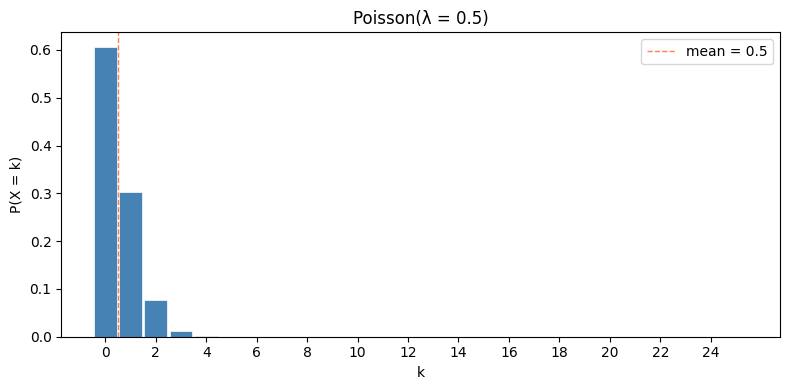

In [2]:
lam = 0.5  # rate λ
k_max = 25  # plot k = 0, …, k_max
k = np.arange(k_max + 1)

# log PMF: k log λ − λ − log(k!), stable for moderate k
log_k_fact = np.zeros(k_max + 1)
log_k_fact[1:] = np.cumsum(np.log(np.arange(1, k_max + 1)))
log_pmf = k * np.log(lam) - lam - log_k_fact
pmf = np.exp(log_pmf)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(k, pmf, width=0.9, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_xlabel("k")
ax.set_ylabel("P(X = k)")
ax.set_title(f"Poisson(λ = {lam})")
ax.set_xticks(k[::2])
ax.axvline(lam, color="coral", linestyle="--", linewidth=1, label=f"mean = {lam}")
ax.legend()
plt.tight_layout()
plt.show()

assert 1 - pmf.sum() < 0.01, "increase k_max"

## Goals scored vs conceded (empirical) from `scores.csv`

Each cell is `opponent_idx:goals_for-goals_against`. For played matches only (`?` weeks skipped), we count normalized frequencies for **goals scored** and **goals conceded** and show both on one chart (grouped bars).

Run the next cell with your kernel’s working directory set to the repo root (`idda/`) so `data/super_league/…` resolves.

team_idx = 1 → Galatasaray
matches with a recorded score: 26 (weeks with ? excluded)
k   P(scored=k)  P(conceded=k)
 0   0.1154        0.4231
 1   0.1923        0.4615
 2   0.0769        0.1154
 3   0.4615        0.0000
 4   0.1154        0.0000
 5   0.0385        0.0000


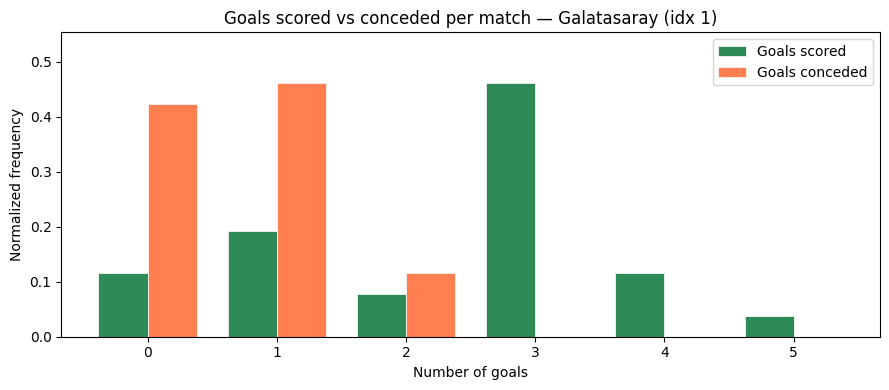

In [5]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Repo root: notebook cwd should be idda/
DATA = Path("data/super_league")
SCORES_CSV = DATA / "scores.csv"
TEAMS_YAML = DATA / "teams.yaml"

TEAM_IDX = 1


def load_idx_to_name(yaml_path: Path) -> dict[int, str]:
    out: dict[int, str] = {}
    for raw in yaml_path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or ":" not in line:
            continue
        name, _, rest = line.partition(":")
        out[int(rest.strip())] = name.strip()
    return out


def parse_goals(cell: str) -> tuple[int, int] | None:
    """Return (goals_for, goals_against), or None if missing (?). Format: opponent:gf-ga."""
    m = re.fullmatch(r"\d+:(\d+)-(\d+)", str(cell).strip())
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))


def normalized_freq(values: list[int]) -> tuple[np.ndarray, np.ndarray]:
    if not values:
        return np.array([], dtype=float), np.array([], dtype=int)
    arr = np.array(values, dtype=int)
    mx = int(arr.max())
    counts = np.bincount(arr, minlength=mx + 1)
    total = counts.sum()
    freq = counts / total if total else counts.astype(float)
    return freq, np.arange(len(freq))


idx_to_name = load_idx_to_name(TEAMS_YAML)
team_name = idx_to_name[TEAM_IDX]
df = pd.read_csv(SCORES_CSV)
row = df.loc[df["team_idx"] == TEAM_IDX].iloc[0]
week_cols = [c for c in df.columns if c.startswith("w")]

goals_scored: list[int] = []
goals_conceded: list[int] = []
for c in week_cols:
    parsed = parse_goals(row[c])
    if parsed is not None:
        gf, ga = parsed
        goals_scored.append(gf)
        goals_conceded.append(ga)

n_matches = len(goals_scored)
freq_s, _ = normalized_freq(goals_scored)
freq_c, _ = normalized_freq(goals_conceded)
k_max = max(len(freq_s), len(freq_c), 1) - 1
ks = np.arange(k_max + 1)
freq_s = np.pad(freq_s, (0, k_max + 1 - len(freq_s)))
freq_c = np.pad(freq_c, (0, k_max + 1 - len(freq_c)))

print(f"team_idx = {TEAM_IDX} → {team_name}")
print(f"matches with a recorded score: {n_matches} (weeks with ? excluded)")
print("k   P(scored=k)  P(conceded=k)")
for k in range(k_max + 1):
    if freq_s[k] > 0 or freq_c[k] > 0 or k <= min(8, k_max):
        print(f"{k:2d}   {freq_s[k]:.4f}        {freq_c[k]:.4f}")

x = np.arange(k_max + 1)
width = 0.38
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width / 2, freq_s, width, label="Goals scored", color="seagreen", edgecolor="white", linewidth=0.5)
ax.bar(x + width / 2, freq_c, width, label="Goals conceded", color="coral", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Number of goals")
ax.set_ylabel("Normalized frequency")
ax.set_title(f"Goals scored vs conceded per match — {team_name} (idx {TEAM_IDX})")
ax.set_xticks(x)
ymax = max(float(freq_s.max()), float(freq_c.max()), 0.05) if n_matches else 0.05
ax.set_ylim(0, ymax * 1.2)
ax.legend()
plt.tight_layout()
plt.show()